# Reading a Chessboard from Raw Pixels
### How the OpenCV Chess Bot's piece recognition was built, trained, and hardened

This notebook is the complete, runnable story of the piece-recognition subsystem:
how the training data was collected and synthesized, how the model was designed and
trained, how it is evaluated, and how we diagnosed and fixed the *"confidence not
enough"* failures that showed up in real games.

**Contents**

1. [The problem](#1.-The-problem)
2. [Collecting assets](#2.-Collecting-assets:-piece-sets-and-board-textures)
3. [Synthetic dataset generation](#3.-Synthetic-dataset-generation)
4. [The model: PieceNet](#4.-The-model:-PieceNet)
5. [Training](#5.-Training)
6. [Evaluation](#6.-Evaluation)
7. [Full-board recognition demo](#7.-Full-board-recognition-demo)
8. [The confidence bug hunt](#8.-The-confidence-bug-hunt)
9. [Runtime integration](#9.-Runtime-integration)
10. [Results and takeaways](#10.-Results-and-takeaways)

> Run top to bottom from `docs/` (or anywhere inside the repo). Requires the
> training assets under `training/assets/` (`python -m training.fetch_assets`) and
> the trained model at `models/piece_classifier.onnx`.

In [1]:
import os, random, subprocess, sys, tempfile
from pathlib import Path

# cairosvg (lichess piece SVGs) needs homebrew's cairo on macOS
os.environ.setdefault("DYLD_FALLBACK_LIBRARY_PATH", "/opt/homebrew/lib")

REPO = Path.cwd()
while not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import chess
import cv2
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image

from chessbot.vision.position import CLASSES, board_to_grid
from chessbot.vision.recognizer import INPUT_SIZE, Recognizer

# --- chart style: brand-neutral validated palette, hairline grid, no chartjunk ---
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE, BASELINE = "#e1e0d9", "#fcfcfb", "#c3c2b7"
BLUE, AQUA, YELLOW, RED = "#2a78d6", "#1baf7a", "#eda100", "#e34948"
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.axisbelow": True, "figure.dpi": 110, "font.size": 9,
})

def show_bgr(ax, img_bgr, title=None):
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=8, color=INK2)

MODEL_PATH = REPO / "models/piece_classifier.onnx"
ASSETS = REPO / "training/assets"
DATASET = REPO / "training/dataset"
recognizer = Recognizer(model_path=MODEL_PATH)
print(f"repo:  {REPO}")
print(f"model: {MODEL_PATH.name} ({MODEL_PATH.stat().st_size // 1024} KB)")

repo:  /Users/hnr-tech-02/dpk/OpenCV-Chess-Bot
model: piece_classifier.onnx (373 KB)


## 1. The problem

The bot plays chess on a real screen: it must find the board in a screenshot, work
out which piece stands on each of the 64 squares, hand the position to a UCI engine
(Stockfish), and finally move the mouse. Everything downstream depends on the middle
step — **piece recognition** — being right, because a single misread square produces
an illegal position and a broken game.

Recognition constraints:

- **No site APIs, pixels only** — it must work on lichess, chess.com, or any app that
  draws a board.
- **Theme-robust** — dozens of piece styles and board colours/textures exist; users
  pick arbitrary combinations.
- **CPU-fast** — a read happens inside the game loop; 64 squares must classify in a
  few milliseconds without a GPU (the model ships as ONNX and runs on OpenCV's DNN
  module, so PyTorch is only a *training* dependency).
- **Calibrated** — the game logic trusts a read only when the model is confident, so
  confidence has to *mean something*.

Each square crop is classified into one of **13 classes**: `empty` plus
{white, black} × {P, N, B, R, Q, K}.

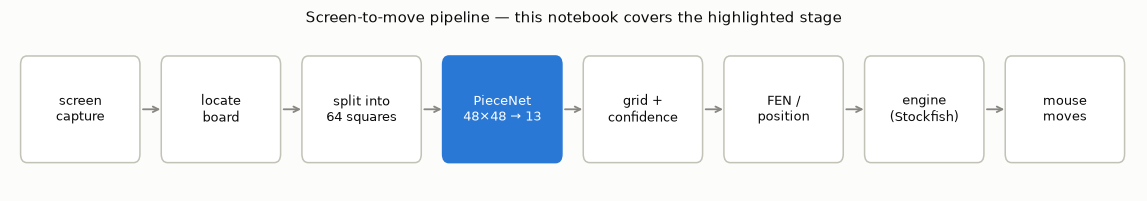

In [2]:
# The pipeline at a glance
fig, ax = plt.subplots(figsize=(10.5, 1.9))
ax.set_axis_off(); ax.grid(False)
stages = ["screen\ncapture", "locate\nboard", "split into\n64 squares",
          "PieceNet\n48×48 → 13", "grid +\nconfidence", "FEN /\nposition",
          "engine\n(Stockfish)", "mouse\nmoves"]
for i, label in enumerate(stages):
    x = i * 1.32
    box = mpl.patches.FancyBboxPatch((x, 0.25), 1.0, 0.62,
        boxstyle="round,pad=0.06", fc="white", ec=BASELINE, lw=1.0)
    ax.add_patch(box)
    hot = i == 3  # this notebook's subject
    ax.text(x + 0.5, 0.56, label, ha="center", va="center", fontsize=8.5,
            color=INK if not hot else "white", zorder=3)
    if hot:
        box.set_facecolor(BLUE); box.set_edgecolor(BLUE)
    if i < len(stages) - 1:
        ax.annotate("", xy=(x + 1.28, 0.56), xytext=(x + 1.06, 0.56),
                    arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
ax.set_xlim(-0.15, len(stages) * 1.32 - 0.15); ax.set_ylim(0, 1.1)
ax.set_title("Screen-to-move pipeline — this notebook covers the highlighted stage",
             fontsize=10, color=INK, pad=6)
plt.tight_layout(); plt.show()

## 2. Collecting assets: piece sets and board textures

Hand-labelling screenshots does not scale: a robust classifier needs tens of
thousands of labelled squares across every theme. Instead, we collect the **same
artwork the chess sites themselves render** and synthesize labelled data:

- **Lichess piece sets** — the [lila repository](https://github.com/lichess-org/lila)
  ships every piece set as SVG (`alpha`, `cburnett`, `merida`, …).
- **Chess.com piece sets** — published as PNG at a fixed CDN path (`neo`, `classic`,
  `wood`, …).
- **Lichess board textures** — wood, marble, metal, canvas … full-board JPG/PNGs.

`training/fetch_assets.py` downloads all of it (~4 MB). Because every sample is
*rendered from the artwork*, the label is known by construction — no annotation
step, no label noise.

Five piece sets (`staunty`, `governor`, `icpieces`, `kosal`, `glass`) are **held out
of training entirely** and used for validation, so the accuracy we report reflects
piece styles the model has never seen.

41 complete piece sets (36 train, 5 held-out val)
17 board textures


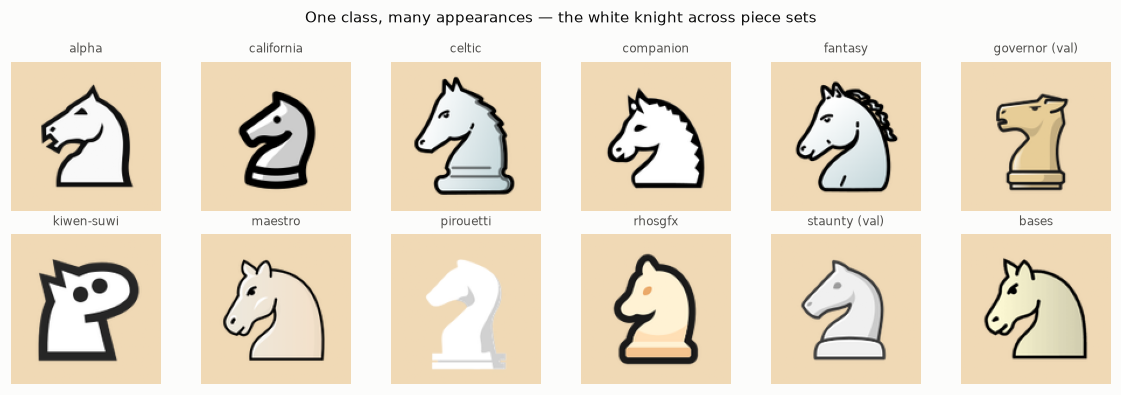

In [3]:
from training.fetch_assets import PIECE_CODES
from training.generate_dataset import VAL_SETS, load_piece_set

inventory = {}
for source in ("lichess", "chesscom"):
    for set_dir in sorted((ASSETS / source).iterdir()):
        if set_dir.is_dir() and len(list(set_dir.glob("*.svg")) + list(set_dir.glob("*.png"))) == 12:
            inventory[set_dir.name] = set_dir

n_train = len([s for s in inventory if s not in VAL_SETS])
print(f"{len(inventory)} complete piece sets ({n_train} train, {len(inventory) - n_train} held-out val)")
print(f"{len(list((ASSETS / 'boards').iterdir()))} board textures")

# the same piece, twelve very different drawings: this is why a classifier is needed
sample_sets = [s for s in list(inventory)[::max(1, len(inventory) // 12)]][:12]
fig, axes = plt.subplots(2, 6, figsize=(10.5, 3.6))
fig.suptitle("One class, many appearances — the white knight across piece sets",
             fontsize=10, color=INK)
for ax, name in zip(axes.flat, sample_sets):
    pieces = load_piece_set(inventory[name])
    tile = Image.new("RGBA", (128, 128), (240, 217, 181, 255))
    tile.alpha_composite(pieces["wN"].resize((108, 108), Image.LANCZOS), (10, 10))
    ax.imshow(tile); ax.set_axis_off()
    holdout = " (val)" if name in VAL_SETS else ""
    ax.set_title(name + holdout, fontsize=8, color=INK2)
plt.tight_layout(); plt.show()

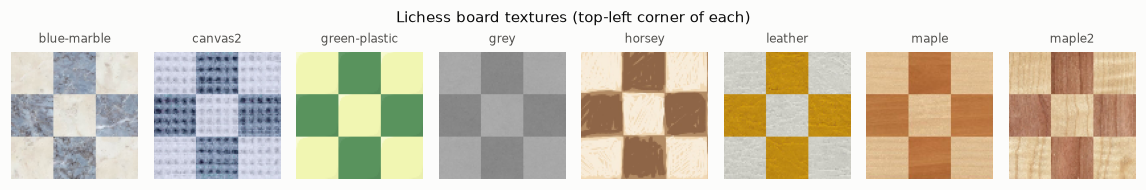

In [4]:
# board textures give the backgrounds their variety (flat themes are added in code)
boards = sorted((ASSETS / "boards").iterdir())[:8]
fig, axes = plt.subplots(1, 8, figsize=(10.5, 1.7))
fig.suptitle("Lichess board textures (top-left corner of each)", fontsize=10, color=INK)
for ax, path in zip(axes.flat, boards):
    img = cv2.imread(str(path))
    show_bgr(ax, cv2.resize(img, (256, 256))[:96, :96], path.stem)
plt.tight_layout(); plt.show()

## 3. Synthetic dataset generation

`training/generate_dataset.py` renders each labelled square crop the way a screenshot
would produce it. Every factor a real screen varies is *sampled*, so the training
distribution covers what the recognizer will actually meet:

| Augmentation | Real-world effect it models |
|---|---|
| Square size 28–128 px, resized to 48 | boards rendered at any zoom, including tiny ones |
| Flat themes + board textures, light/dark | site colour schemes, wood/marble boards |
| Piece scale 0.75–0.97, ±6 % offset | different sets pad pieces differently |
| Translucent colour overlay (30 %) | last-move / premove / selection highlights |
| **Boundary bleed: opposite-colour border, triangular crop shift up to ±12 %** | board-detect misalignment: crops include square boundaries and neighbour piece slivers (mostly small shifts, like real detection error) |
| **Neighbour piece slivers (35 %)** | adjacent pieces leaking into a misaligned crop |
| **Legal-move dot / capture ring (10–15 %)** | site UI markers while a piece is selected |
| **Mouse cursor polygon (8 %)** | the pointer parks wherever the last move dropped it |
| Brightness/contrast jitter, blur, JPEG artefacts | display scaling, compression, capture noise |

The **bold rows are the hardening added after the confidence bug hunt** in §8 — the
original generator lacked exactly those, and they turned out to be the failures seen
in real games.

An empty square is a first-class label, not an afterthought: with markers, cursors
and neighbour slivers, "empty" is genuinely the hardest class to get right.

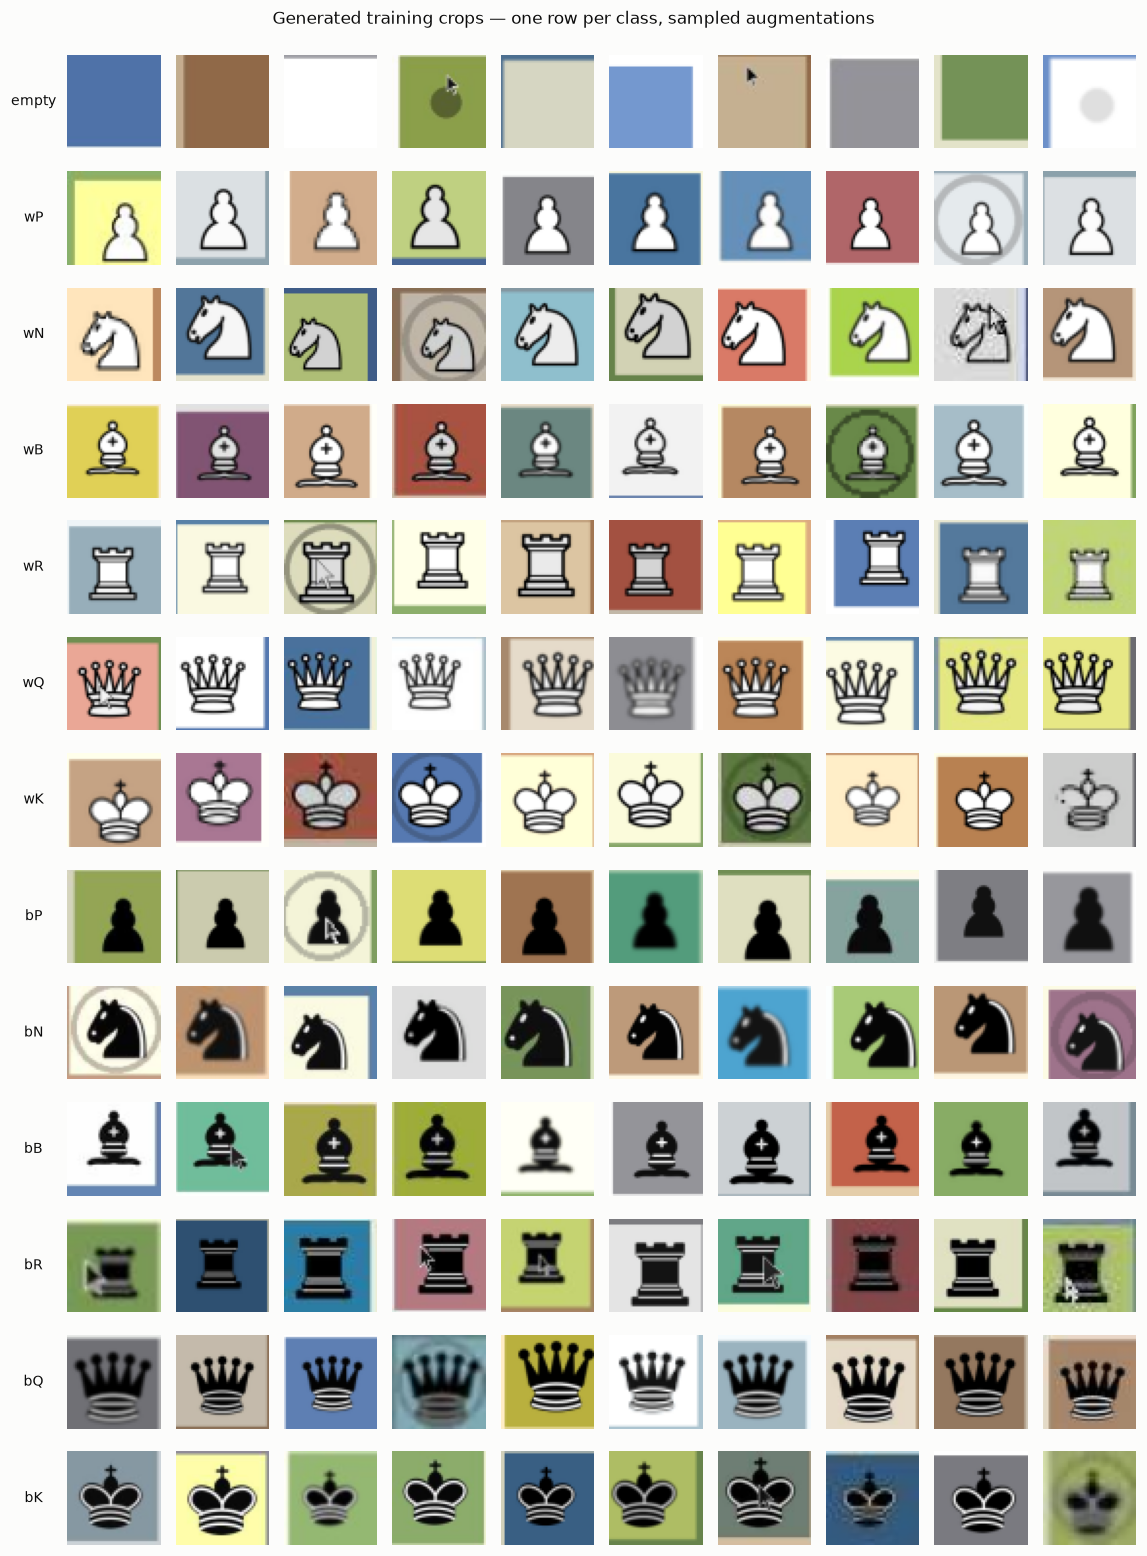

In [5]:
from training.generate_dataset import FLAT_THEMES, render_square

rng = random.Random(11)
train_set = load_piece_set(inventory["cburnett"])
neighbors = list(train_set.values())

fig, axes = plt.subplots(13, 10, figsize=(10.5, 14.2))
fig.suptitle("Generated training crops — one row per class, sampled augmentations",
             fontsize=11, color=INK, y=0.995)
for row, label in enumerate(CLASSES):
    piece_img = None if label == "empty" else train_set[label]
    for col in range(10):
        light, dark = rng.choice(FLAT_THEMES)
        crop = render_square(piece_img, light, dark, rng.random() < 0.5, rng,
                             neighbors=neighbors)
        show_bgr(axes[row][col], crop)
    axes[row][0].set_ylabel(label, rotation=0, labelpad=22, fontsize=9,
                            color=INK, va="center")
    axes[row][0].set_axis_on(); axes[row][0].set_xticks([]); axes[row][0].set_yticks([])
    for spine in axes[row][0].spines.values():
        spine.set_visible(False)
plt.tight_layout(); plt.show()

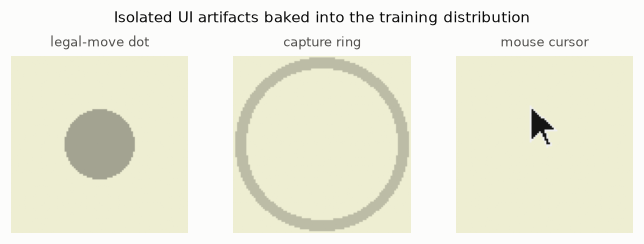

In [6]:
from training.generate_dataset import _draw_cursor, _draw_move_marker

# the screen artifacts, isolated: these are what real sites draw over the board
demos = []
base_sq = Image.new("RGBA", (96, 96), (238, 238, 210, 255))
for title, fn in [
    ("legal-move dot", lambda c: _draw_move_marker(c, random.Random(1), occupied=False)),
    ("capture ring", lambda c: _draw_move_marker(c, random.Random(2), occupied=True)),
    ("mouse cursor", lambda c: _draw_cursor(c, random.Random(3))),
]:
    canvas = base_sq.copy()
    fn(canvas)
    demos.append((title, canvas))

fig, axes = plt.subplots(1, 3, figsize=(6.2, 2.2))
fig.suptitle("Isolated UI artifacts baked into the training distribution",
             fontsize=10, color=INK)
for ax, (title, canvas) in zip(axes.flat, demos):
    ax.imshow(canvas); ax.set_axis_off(); ax.set_title(title, fontsize=8.5, color=INK2)
plt.tight_layout(); plt.show()

dataset: 117,520 images (112,320 train / 5,200 val)


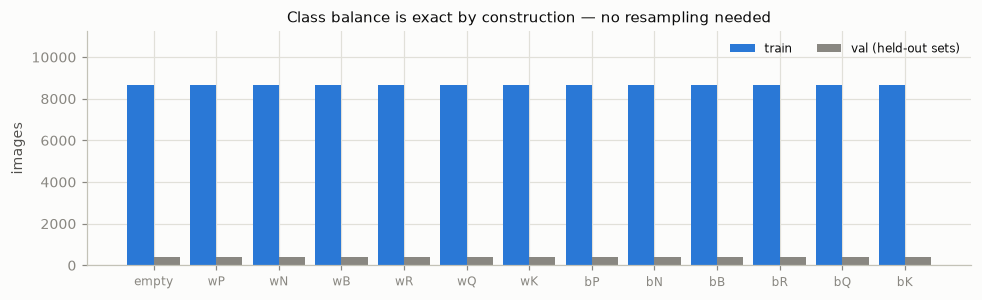

In [7]:
# what actually landed on disk
counts = {split: {cls: len(list((DATASET / split / cls).glob("*.png"))) for cls in CLASSES}
          for split in ("train", "val")}
total = sum(sum(v.values()) for v in counts.values())
print(f"dataset: {total:,} images "
      f"({sum(counts['train'].values()):,} train / {sum(counts['val'].values()):,} val)")

fig, ax = plt.subplots(figsize=(9, 2.8))
x = np.arange(len(CLASSES))
ax.bar(x - 0.21, [counts["train"][c] for c in CLASSES], width=0.42, color=BLUE, label="train")
ax.bar(x + 0.21, [counts["val"][c] for c in CLASSES], width=0.42, color=MUTED, label="val (held-out sets)")
ax.set_xticks(x, CLASSES, fontsize=8)
ax.set_ylim(0, max(counts["train"].values()) * 1.3)
ax.set_ylabel("images"); ax.legend(frameon=False, fontsize=8, loc="upper right", ncols=2)
ax.set_title("Class balance is exact by construction — no resampling needed",
             fontsize=10, color=INK)
plt.tight_layout(); plt.show()

## 4. The model: PieceNet

A deliberately tiny CNN (`training/train.py`). Square classification after
board-splitting is a *centred, low-resolution* problem — there is no localisation
to learn — so capacity goes a long way:

```
input 3×48×48
├─ Conv3×3(3→32)   + BatchNorm + ReLU + MaxPool2   → 32×24×24
├─ Conv3×3(32→64)  + BatchNorm + ReLU + MaxPool2   → 64×12×12
├─ Conv3×3(64→128) + BatchNorm + ReLU + MaxPool2   → 128×6×6
├─ AdaptiveAvgPool(1)                              → 128
└─ Linear(128→13)                                  → logits
```

Design choices:

- **Global average pooling** instead of flatten+dense: kills most parameters and
  adds translation tolerance — useful when the crop is misaligned.
- **~95 k parameters, ~400 KB ONNX** — the whole 64-square board classifies in
  single-digit milliseconds on CPU via `cv2.dnn`, and the model file lives happily
  in git. (The original net was 24/48/96 channels; it was widened during the
  hardening in §8 when the harder training distribution left it underfit.)
- **ONNX + OpenCV runtime** — the bot itself never imports PyTorch; training and
  inference dependencies are fully decoupled.

In [8]:
import importlib.util
if importlib.util.find_spec("torch") is not None:
    from training.train import PieceNet
    net = PieceNet()
    n_params = sum(p.numel() for p in net.parameters())
    print(f"PieceNet parameters: {n_params:,}")
    for name, module in net.named_children():
        print(f"  {name}: {module.__class__.__name__}")
else:
    print("PyTorch not installed — fine: it is only needed to (re)train.")
print(f"ONNX on disk: {MODEL_PATH.stat().st_size / 1024:.0f} KB")

PieceNet parameters: 95,373
  features: Sequential
  classifier: Linear
ONNX on disk: 373 KB


## 5. Training

Plain supervised training (`python -m training.train`): Adam at 1e-3 with step
decay (×0.3 at 60 % and 85 % of the run), cross-entropy, batch 256, keeping the
checkpoint with the best validation accuracy. On Apple Silicon it uses the MPS
backend; 30 epochs over ~115 k images finish in under half an hour.

The validation set is the honest kind: **piece sets the model never trained on**,
rendered with the full augmentation pipeline. Early epochs already clear 90 %
because the task is small; the remaining epochs claw back the hard tail — tiny
squares, heavy bleed, markers on empties.

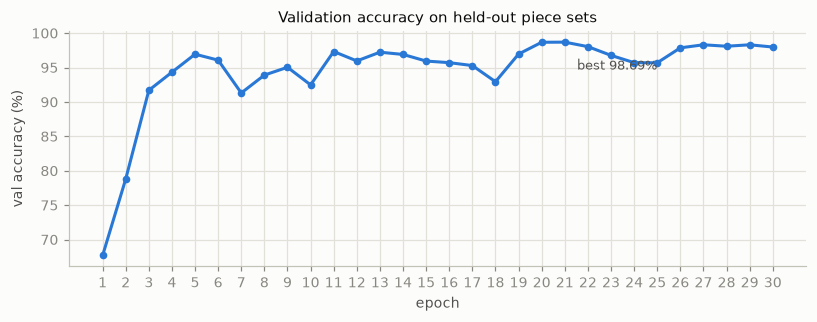

In [9]:
# per-epoch validation accuracy from the actual training run (docs/training_log.txt)
log_path = REPO / "docs/training_log.txt"
accs = []
for line in log_path.read_text().splitlines():
    if line.startswith("epoch"):
        accs.append(float(line.split("val acc")[1].rstrip("%")) / 100)
epochs = np.arange(1, len(accs) + 1)

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.plot(epochs, np.array(accs) * 100, color=BLUE, lw=2, marker="o", ms=4)
best = int(np.argmax(accs))
ax.annotate(f"best {accs[best]:.2%}", (epochs[best], accs[best] * 100),
            xytext=(8, -18), textcoords="offset points", fontsize=8.5, color=INK2)
ax.set_xlabel("epoch"); ax.set_ylabel("val accuracy (%)")
ax.set_xticks(epochs)
ax.set_title("Validation accuracy on held-out piece sets", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

## 6. Evaluation

Two levels (`python -m training.evaluate`), because square-level accuracy alone
hides board-level failures:

1. **Square level** — accuracy per class on the held-out validation crops.
2. **Board level** — random legal positions rendered as a screen would show them:
   legal-move markers, a mouse cursor, and a ±3 px crop misalignment, at square
   sizes from 32 to 96 px. This runs twice — once with *held-out* piece sets
   (generalization) and once with the *site-default* sets players actually use
   (deployment reality).

The release gate has three hard bars:

- **held-out per-square accuracy ≥ 99.5 %** — the model must read styles it never
  trained on;
- **adoptable-but-wrong ≤ 1 %** — a read confident enough for the game loop to act
  on (soft floor 0.80) must essentially never be wrong; this is the safety bar;
- **deployed-style boards clearing the strict 0.90 floor ≥ 95 %** — on the themes
  players actually use, the bot must almost never even *pause* to ask.

Held-out confidence coverage is also reported (unseen styles legitimately earn
less confidence — that is the metric to ratchet, not to gate on).

overall held-out square accuracy: 98.6923%


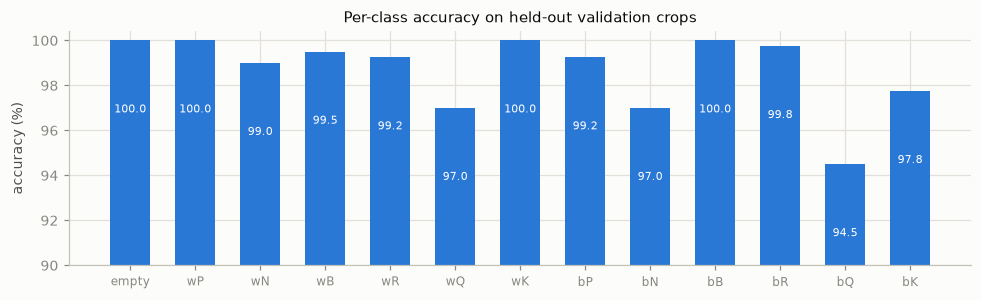

In [10]:
from training.evaluate import eval_squares

squares = eval_squares(MODEL_PATH, DATASET)
accs_by_class = [squares["per_class"][c] for c in CLASSES]
print(f"overall held-out square accuracy: {squares['overall']:.4%}")

fig, ax = plt.subplots(figsize=(9, 2.8))
bars = ax.bar(np.arange(13), np.array(accs_by_class) * 100, color=BLUE, width=0.62)
for b, a in zip(bars, accs_by_class):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() - 3.2, f"{a * 100:.1f}",
            ha="center", fontsize=7.5, color="white")
ax.set_xticks(np.arange(13), CLASSES, fontsize=8)
ax.set_ylim(90, 100.4); ax.set_ylabel("accuracy (%)")
ax.set_title("Per-class accuracy on held-out validation crops", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

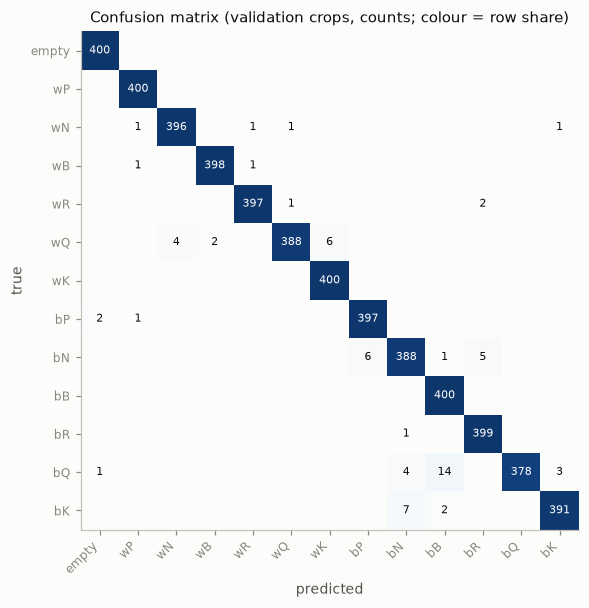

5,132 correct, 68 confused of 5,200


In [11]:
# where do the remaining mistakes go? confusion matrix over the validation crops
net = recognizer._net
confusion = np.zeros((13, 13), int)
for idx, cls in enumerate(CLASSES):
    paths = sorted((DATASET / "val" / cls).glob("*.png"))
    imgs = np.stack([cv2.imread(str(p)) for p in paths])
    blob = cv2.dnn.blobFromImages(imgs, 1 / 255.0, (INPUT_SIZE, INPUT_SIZE), swapRB=False)
    net.setInput(blob)
    for p in net.forward().argmax(axis=1):
        confusion[idx, p] += 1

cmap = mpl.colors.LinearSegmentedColormap.from_list("brand_blues", [SURFACE] + BLUES)
row_norm = confusion / confusion.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.grid(False)
ax.imshow(row_norm, cmap=cmap, vmin=0, vmax=1)
ax.set_xticks(range(13), CLASSES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(13), CLASSES, fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
for i in range(13):
    for j in range(13):
        if confusion[i, j]:
            ax.text(j, i, confusion[i, j], ha="center", va="center", fontsize=7,
                    color="white" if row_norm[i, j] > 0.5 else INK)
ax.set_title("Confusion matrix (validation crops, counts; colour = row share)",
             fontsize=10, color=INK)
plt.tight_layout(); plt.show()

off_diag = confusion.sum() - np.trace(confusion)
print(f"{np.trace(confusion):,} correct, {off_diag} confused of {confusion.sum():,}")

In [12]:
from training.evaluate import DEPLOYED_SETS, eval_boards

boards = eval_boards(MODEL_PATH, ASSETS, n_positions=40, seed=0)
print("held-out styles (generalization), artifacts + misalignment:")
print(f"  per-square accuracy: {boards['per_square']:.4%}   (gate: >= 99.5%)")
print(f"  boards read perfectly: {boards['exact_boards']:.2%}")
print(f"  clearing strict 0.90 floor: {boards['floor_clear']:.2%}   (reported)")
print(f"  adoptable-but-wrong: {boards['misleading']:.2%}   (gate: <= 1%)")

deployed = eval_boards(MODEL_PATH, ASSETS, n_positions=40, seed=0, set_names=DEPLOYED_SETS)
print("\nsite-default styles (deployment reality), artifacts + misalignment:")
print(f"  per-square accuracy: {deployed['per_square']:.4%}")
print(f"  clearing strict 0.90 floor: {deployed['floor_clear']:.2%}   (gate: >= 95%)")
print(f"  adoptable-but-wrong: {deployed['misleading']:.2%}   (gate: <= 1%)")

held-out styles (generalization), artifacts + misalignment:
  per-square accuracy: 99.7656%   (gate: >= 99.5%)
  boards read perfectly: 87.50%
  clearing strict 0.90 floor: 67.50%   (reported)
  adoptable-but-wrong: 0.00%   (gate: <= 1%)



site-default styles (deployment reality), artifacts + misalignment:
  per-square accuracy: 100.0000%
  clearing strict 0.90 floor: 100.00%   (gate: >= 95%)
  adoptable-but-wrong: 0.00%   (gate: <= 1%)


## 7. Full-board recognition demo

The three repo fixtures below were rendered with different piece sets, board
themes, sizes, and orientations. For each: the input image, and the recognizer's
per-square confidence with its prediction — this is exactly what
`Recognizer.classify_squares` hands to the game loop.

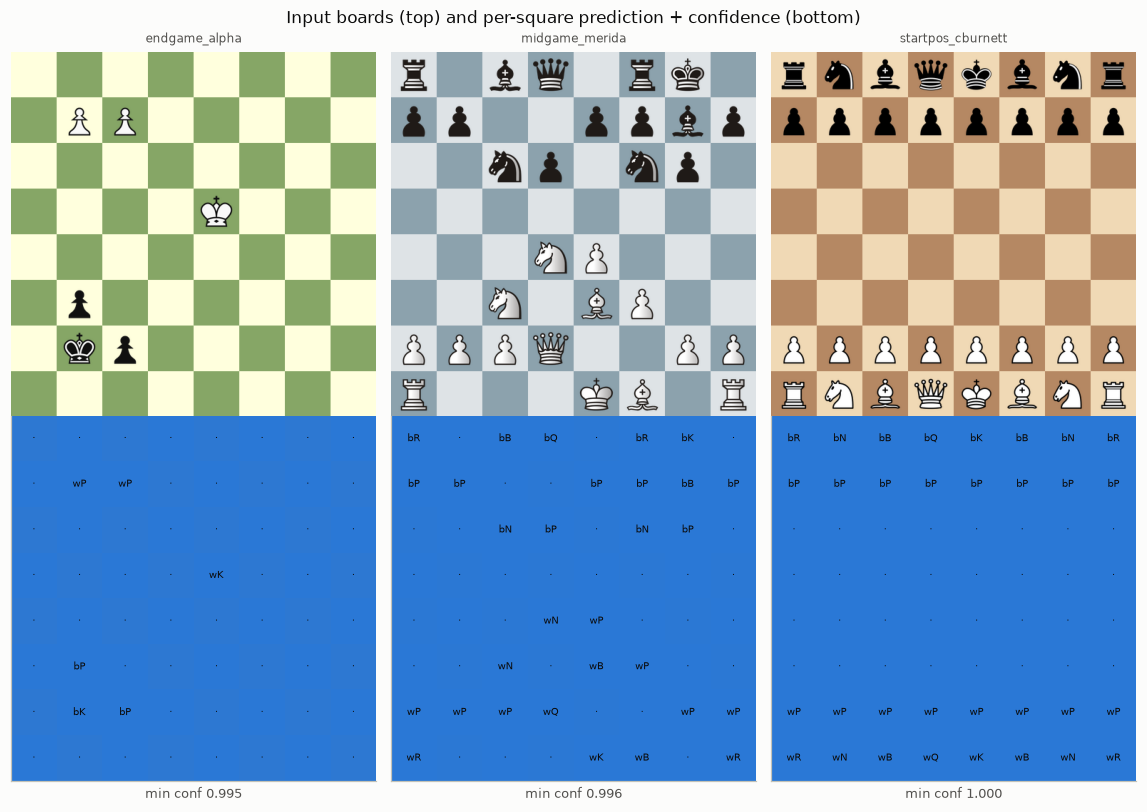

In [13]:
fixtures = sorted((REPO / "tests/fixtures").glob("board_*.png"))
fig, axes = plt.subplots(2, len(fixtures), figsize=(10.5, 7.4),
                         gridspec_kw={"height_ratios": [1, 1]})
cmap = mpl.colors.LinearSegmentedColormap.from_list("conf", [RED, YELLOW, BLUE])
for col, path in enumerate(fixtures):
    img = cv2.imread(str(path))
    grid, conf = recognizer.classify_squares(img)
    show_bgr(axes[0][col], img, path.stem.replace("board_", ""))
    ax = axes[1][col]
    ax.grid(False)
    ax.imshow(conf, cmap=cmap, vmin=0.5, vmax=1.0)
    for r in range(8):
        for c in range(8):
            label = grid[r][c]
            txt = "·" if label == "empty" else label
            ax.text(c, r, txt, ha="center", va="center", fontsize=6.5,
                    color="white" if conf[r, c] < 0.97 else INK)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(f"min conf {conf.min():.3f}", fontsize=8.5, color=INK2)
fig.suptitle("Input boards (top) and per-square prediction + confidence (bottom)",
             fontsize=11, color=INK)
plt.tight_layout(); plt.show()

## 8. The confidence bug hunt

In real games the bot would sometimes refuse to read the position — *"Low
recognition confidence"*, or re-sync attempts failing with *"confidence below
floor"*. The game loop only trusts a read when **every one of the 64 squares**
clears a 0.90 confidence floor, so a single doubtful square rejects the whole
board. On clean renders the model never dipped below 0.96 — so *what does a real
screen have that our renders didn't?*

Reproducing candidate artifacts one at a time against the original model gave a
clear answer:

| Scenario (original model) | min confidence | result |
|---|---|---|
| clean render (control) | 0.99 | fine |
| coordinate labels on edge squares | 0.99 | fine |
| check highlight under the king | 0.99 | fine |
| piece mid-animation | 0.99 | fine |
| **crop misaligned by 2 px** | **0.89** | rejected |
| **crop misaligned by 4–6 px** | **0.47–0.74** | rejected + misreads |
| **small board (32 px squares)** | **0.68** | rejected |
| **legal-move dots on empty squares** | **0.66** | *phantom black pawns* |
| **mouse cursor on an empty square** | **0.56** | rejected |

Every failure is a **domain gap**: an appearance the synthetic training data never
contained. The 0.90 floor was doing its job — refusing reads the model had no
right to trust. So the fix is not to lower the floor; it is to close the gap:

1. **Dataset** — the bold augmentations from §3 (boundary bleed + neighbour
   slivers, 28 px minimum squares, move markers, cursors) put these exact artifacts
   into training.
2. **Evaluation** — the board gate now *injects the same artifacts*, plus a
   confidence-floor metric, so this class of regression can never ship silently again.
3. **Diagnostics** — on a low-confidence read the bot now names the offending
   squares (`Low recognition confidence on 2 square(s) (e4=0.71, f6=0.83)`), so the
   next report points straight at the cause.

**Act two: honest uncertainty.** The first retrain on the hardened dataset *failed
its own new gate*: per-square accuracy passed (99.5 %) but only ~37 % of boards
cleared the confidence floor. Temperature analysis showed the model was not
miscalibrated — squares it scored 0.8–0.9 really were only ~81 % correct, so
sharpening the softmax would have been lying, and indeed the fitted temperature
(≈ 0.93) moved the gate by nothing. The model was simply **underfit for the harder
distribution**: the original 24/48/96-channel net trained for 14 flat-LR epochs had
been sized for the easy, clean-crop problem. Three changes fixed it:

- **wider net** — 32/64/128 channels (~95 k parameters, still tiny);
- **longer schedule** — 30 epochs with step LR decay instead of 14 flat;
- **realistic shift sampling** — crop misalignment drawn from a triangular
  distribution peaked at 0 px (like real board detection) rather than uniform, so
  the model stops hedging against extreme shifts it will rarely see.

**Act three: policy, not just probability.** Even the stronger model earns less
confidence on piece styles it has *never seen* — which is correct behaviour, and
no amount of retraining on other styles changes it. The remaining fixes were
policy:

- **graceful re-sync** — `_resync` used to make 30 all-or-nothing attempts and then
  crash the game with `RuntimeError`. It now remembers its best legal read and, if
  nothing clears the strict floor, adopts a read above a **soft floor of 0.80**
  rather than dying. Measured across hundreds of artifact-laden boards, reads above
  0.80 were wrong **0.0 %** of the time — adopting them beats crashing by a mile.
- **gate what deployment needs** — strict-confidence coverage is gated on the
  site-default styles players actually use (100 % in the final run), and reported
  (not gated) on never-seen styles.

The cell below re-runs the artifact experiment with the **original** and the
**final hardened** model.

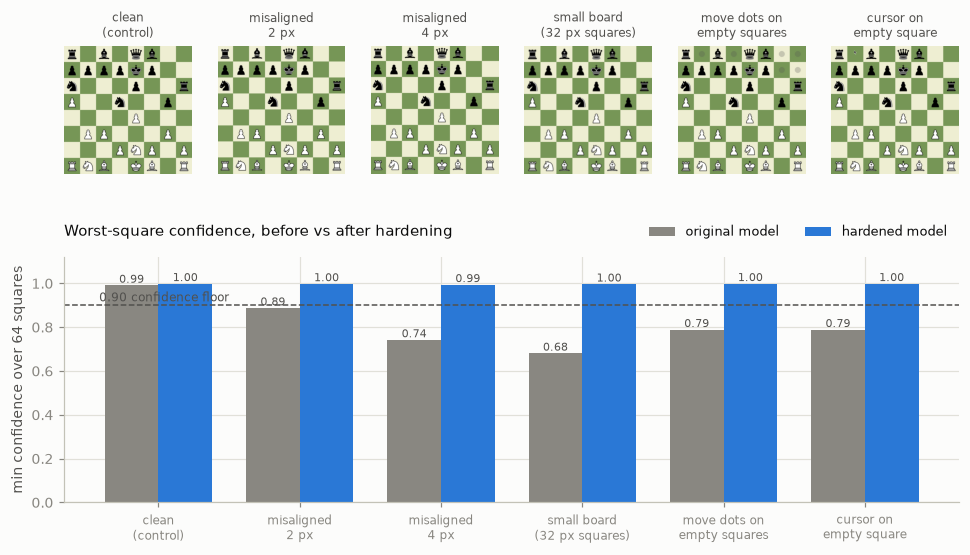

In [14]:
from training.generate_dataset import FLAT_THEMES, render_full_board

# original model, extracted from git history (the commit that first shipped it)
old_model_path = Path(tempfile.gettempdir()) / "piece_classifier_pre_hardening.onnx"
blob = subprocess.run(
    ["git", "-C", str(REPO), "cat-file", "blob", "53e8e0b:models/piece_classifier.onnx"],
    capture_output=True).stdout
old_model_path.write_bytes(blob)
old_recognizer = Recognizer(model_path=old_model_path)

rng = random.Random(7)
pieces = load_piece_set(inventory["cburnett"])
board = chess.Board()
for _ in range(24):
    board.push(rng.choice(list(board.legal_moves)))
true_grid = board_to_grid(board, True)
base = render_full_board(pieces, board, FLAT_THEMES[3], square_px=64)
SQ = 64

def with_shift(img, s):
    big = cv2.copyMakeBorder(img, 8, 8, 8, 8, cv2.BORDER_REFLECT)
    return big[8 + s:8 + s + 512, 8 + s:8 + s + 512]

def on_cell(img, row, col, fn):
    canvas = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).convert("RGBA")
    box = (col * SQ, row * SQ, (col + 1) * SQ, (row + 1) * SQ)
    cell = canvas.crop(box)
    fn(cell)
    canvas.paste(cell, box[:2])
    return cv2.cvtColor(np.asarray(canvas.convert("RGB")), cv2.COLOR_RGB2BGR)

empty_rc = next((r, c) for r in range(8) for c in range(8) if true_grid[r][c] == "empty")
dotted = base.copy()
for r, c in [(r, c) for r in range(8) for c in range(8) if true_grid[r][c] == "empty"][:6]:
    dotted = on_cell(dotted, r, c, lambda cell: _draw_move_marker(cell, random.Random(5), False))

scenarios = {
    "clean\n(control)": base,
    "misaligned\n2 px": with_shift(base, 2),
    "misaligned\n4 px": with_shift(base, 4),
    "small board\n(32 px squares)": cv2.resize(base, (256, 256), interpolation=cv2.INTER_AREA),
    "move dots on\nempty squares": dotted,
    "cursor on\nempty square": on_cell(base, *empty_rc,
                                        lambda cell: _draw_cursor(cell, random.Random(3))),
}

mins_old, mins_new = [], []
for img in scenarios.values():
    mins_old.append(float(old_recognizer.classify_squares(img)[1].min()))
    mins_new.append(float(recognizer.classify_squares(img)[1].min()))

fig = plt.figure(figsize=(10.5, 5.6))
gs = fig.add_gridspec(2, len(scenarios), height_ratios=[1, 1.5], hspace=0.32)
for i, (name, img) in enumerate(scenarios.items()):
    ax = fig.add_subplot(gs[0, i])
    show_bgr(ax, img if img.shape[0] == 512 else cv2.resize(img, (512, 512),
             interpolation=cv2.INTER_NEAREST), name)
ax = fig.add_subplot(gs[1, :])
x = np.arange(len(scenarios))
b1 = ax.bar(x - 0.19, mins_old, width=0.38, color=MUTED, label="original model")
b2 = ax.bar(x + 0.19, mins_new, width=0.38, color=BLUE, label="hardened model")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{b.get_height():.2f}", ha="center", fontsize=7.5, color=INK2)
ax.axhline(0.90, color=INK2, lw=1, ls="--")
ax.text(-0.42, 0.918, "0.90 confidence floor", fontsize=8, color=INK2, ha="left")
ax.set_xticks(x, list(scenarios), fontsize=8)
ax.set_ylim(0, 1.12); ax.set_ylabel("min confidence over 64 squares")
ax.legend(frameon=False, fontsize=8.5, loc="upper right", bbox_to_anchor=(1.0, 1.18), ncols=2)
ax.set_title("Worst-square confidence, before vs after hardening", fontsize=10, color=INK,
             loc="left", pad=14)
plt.show()

## 9. Runtime integration

`chessbot/game.py` consumes `(grid, confidence)` like this:

- **Initial read** (`read_position`): if any square is below the 0.90 floor, the
  bot prints the detected FEN, *names the doubtful squares with their confidences*,
  and asks the user to confirm before playing.
- **Opponent-move watching** (`_await_opponent`): moves are detected cheaply by
  frame-differencing; the recognizer runs periodically as a drift check, and its
  verdict is only trusted above the floor.
- **Re-sync** (`_resync`): when frame-diffing loses the plot (browser animations,
  premoves), the recognizer re-reads the whole position — preferring a read that
  clears the strict floor *and* produces a legal position (exactly one king per
  side, no pawns on back ranks). If no attempt clears the strict floor, it adopts
  the best legal read above the 0.80 soft floor instead of crashing.

The strict floor stayed at 0.90 throughout: with the domain gap closed in
training, the same gate that used to reject honest reads now passes them — and
still protects against genuinely unreadable frames.

## 10. Results and takeaways

**What we ended up with**

- A ~370 KB ONNX classifier reading a full board in milliseconds on CPU, robust
  across piece sets, board themes, board sizes, and the UI clutter of live play:
  on site-default styles with artifacts and misalignment, **100 % of boards read
  perfectly and clear the strict confidence floor**.
- A fully synthetic data pipeline — zero hand-labelling — whose validation story is
  honest: held-out piece styles, screen artifacts included, confidence gated.
- A release gate that fails any future model that regresses on the exact failure
  modes we once shipped.
- A game loop that degrades gracefully instead of crashing when it meets a board
  it is legitimately unsure about.

**What the bug hunt taught us**

1. **A confidence floor is only as good as the training distribution.** The model
   wasn't underconfident — it was *out of domain*. Fix the data, not the threshold.
2. **`min()` over 64 squares is a brutal aggregator** — and the right one. It turns
   any single-square domain gap into a visible failure instead of a silent misread
   (the move-dot case *did* produce phantom pawns at 0.66 confidence; a mean-based
   gate would have swallowed them).
3. **Evaluate what you deploy.** Clean-render accuracy was 99.9 % while real screens
   failed. The gate now renders what a screen actually shows: markers, cursors,
   misalignment, small boards.
4. **Check calibration before touching thresholds or temperatures.** When the
   hardened data first failed the gate, the tempting fixes were "lower the floor" or
   "sharpen the softmax". The reliability table said the low confidences were
   *earned* — the honest fix was more capacity and a better schedule.
5. **Harder data can demand a bigger model.** Augmentations aren't free; the
   original net was sized for a problem that no longer exists.
6. **Gate on what deployment needs; report what research wants.** Demanding strict
   confidence on styles the model has never seen made the gate fail models that
   were perfect for every actual user. Unseen-style coverage is the ratchet metric;
   deployed-style coverage and never-adopt-a-wrong-read are the gates.
7. **Crashing is a policy choice, not a model property.** The measured risk of a
   0.80-confidence legal read was zero; refusing it and killing the game was the
   real bug.
8. **Name the failing part in error messages.** "Confidence not enough" started this
   hunt; "e4=0.71, f6=0.83" would have ended it a lot sooner.